# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Meena Sakthi

**Date:** 09/09/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.

# Uploaded to my GitHub repo

Q: 2.1

Q: 2.2


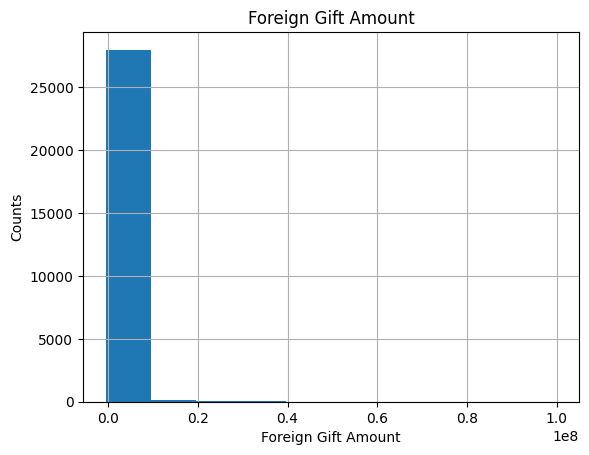

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
Patterns: The distribution  of Foreign Gidt Amount is skewed to the right. Most gifts are relatively small, however a small number of very large gifts extend the distribution to the right. The median gift is $94615 and mean is $588233. The max is $100 million and there are also negative gift amounts with a min of -$537770

Q: 2.3


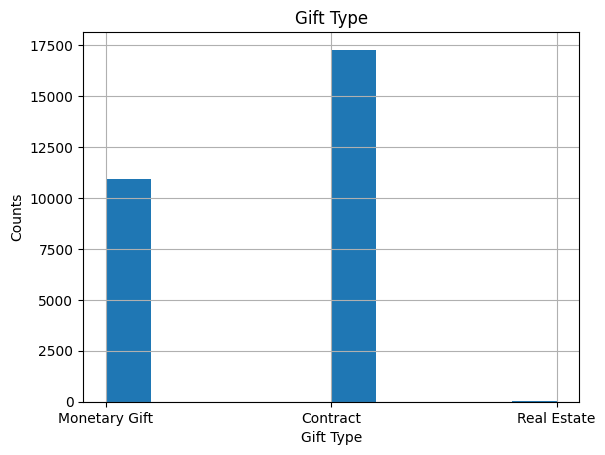

Proportion of the gift type being Monetary:  0.3875128450444704
Proportion of the gift type being Real Estate:  0.00038978065979235324
Proportion of the gift type being Contracts:  0.6120973742957372

Q: 2.4


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


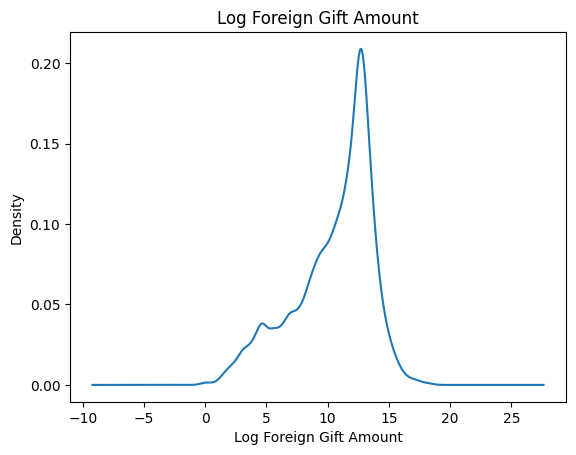

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


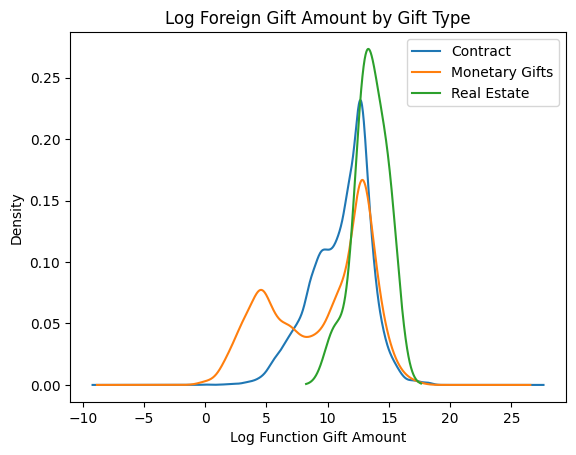

Findings: Contracts and monetary gifts have similar main peaks, but monetray gifts have a wider range and more small valye gifts. Real estate gifts seem to be concentrated at higher values even though there are only 11 real estate gifts

Q: 2.5
Top 15 countries by number of gifts
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Top 15 countries by amount
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN      

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Q: 2.1")
df = pd.read_csv("/content/A02-eda-and-visualization/data/ForeignGifts_edu.csv")
df.head()

print("")
print("Q: 2.2")
plt.figure()
df["Foreign Gift Amount"].hist()
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Counts")
plt.title("Foreign Gift Amount")
plt.show()
print(df["Foreign Gift Amount"].describe())
print("Patterns: The distribution  of Foreign Gidt Amount is skewed to the right. Most gifts are relatively small, however a small number of very large gifts extend the distribution to the right. The median gift is $94615 and mean is $588233. The max is $100 million and there are also negative gift amounts with a min of -$537770")


print("")
print("Q: 2.3")

df["Gift Type"].hist()
plt.xlabel("Gift Type")
plt.ylabel("Counts")
plt.title("Gift Type")
plt.show()

#Calculating the proportions
Monetary = df[df["Gift Type"] == "Monetary Gift"]["Gift Type"].count()
RealEstate = df[df["Gift Type"] == "Real Estate"]["Gift Type"].count()
Contracts = df[df["Gift Type"] == "Contract"]["Gift Type"].count()
Total = df["Gift Type"].count()
print(f"Proportion of the gift type being Monetary: ", Monetary/Total)
print(f"Proportion of the gift type being Real Estate: ", RealEstate/Total)
print(f"Proportion of the gift type being Contracts: ", Contracts/Total)


print("")
print("Q: 2.4")
log_gift = np.log(df['Foreign Gift Amount'])
log_gift.plot(kind="density")
plt.xlabel("Log Foreign Gift Amount")
plt.ylabel("Density")
plt.title("Log Foreign Gift Amount")
plt.show()

contract = df[df['Gift Type'] == "Contract"]
MonGifts = df[df["Gift Type"]== 'Monetary Gift']
Realestate = df[df["Gift Type"]=="Real Estate"]

np.log(contract["Foreign Gift Amount"]).plot(kind="density", label="Contract")
np.log(MonGifts["Foreign Gift Amount"]).plot(kind="density", label="Monetary Gifts")
np.log(Realestate["Foreign Gift Amount"]).plot(kind="density", label="Real Estate")

plt.xlabel("Log Function Gift Amount")
plt.ylabel("Density")
plt.title("Log Foreign Gift Amount by Gift Type")
plt.legend()
plt.show()

print("Findings: Contracts and monetary gifts have similar main peaks, but monetray gifts have a wider range and more small valye gifts. Real estate gifts seem to be concentrated at higher values even though there are only 11 real estate gifts")

print("")
print("Q: 2.5")
c_count =df.groupby("Country of Giftor")["Foreign Gift Amount"].count()
c_count = c_count.sort_values(ascending=False)
print("Top 15 countries by number of gifts")
print(c_count.head(15))

c_amount =df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
c_amount = c_amount.sort_values(ascending=False)
print("Top 15 countries by amount")
print(c_amount.head(15))


print("")
print("Q: 2.6")
giftoramount = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()
giftoramount = giftoramount.sort_values(ascending=False)
print(giftoramount.head(10))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]